# Lab 2 · What an average hides
## Data Science Fundamentals — Week 2: Describing Data
**Mohammad Sabokrou · New Uzbekistan University**

**Your job:** use evidence to explain data and make a defensible decision. The Python is provided; programming complexity earns no extra credit.

**Name:** Diyorbek Xasanboyev   
**Student ID:** 250275

### How to work
1. Open this notebook in Google Colab or Jupyter. Run the setup with your own ID.
2. Work from top to bottom. Where asked, write a prediction **before** running the next cell. Keep the prediction even if it is wrong; explain what you learned.
3. Double-click an **Answer** cell to write. Use your own generated numbers and refer to specific plots. A number without an interpretation is incomplete.
4. Run the supplied code; change only the explicitly labelled settings. You are responsible for understanding and explaining the results you submit.
5. Keep the same ID throughout. Restart and run all cells after finishing; save the notebook with outputs.

**Suggested pace:** setup 5 min; sections 1–8: 10, 15, 15, 15, 15, 10, 15, 15 min; final check 5 min (120 min total). Finish the written reflection after class if needed.

### What varies between students?
Your ID determines the data, eight-number exercise, selected record, histogram settings, and decision scenario. The concepts and workload stay comparable. Reusing an ID gives the same case. Different IDs are not a guarantee that every individual number differs.

All records are **synthetic teaching data**, not real university records. There are no downloads, joins, or missing code blocks to debug.

**Evidence standard:** answers should contain a claim, a number or plot observation from your case, and a reason or limitation. We assess statistical reasoning, appropriate methods, and reproducible evidence—not Python fluency.

In [1]:
# SETUP — edit only STUDENT_ID. Integers and quoted IDs both work.
STUDENT_ID = "250275"
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

STUDENT_ID = str(STUDENT_ID).strip()
if not (STUDENT_ID.isascii() and STUDENT_ID.isdigit() and 6 <= len(STUDENT_ID) <= 12):
    raise ValueError("Replace YOUR_ID with your own 6–12 digit student ID, then run again.")
seed = int.from_bytes(hashlib.sha256(('FDS-Lab2-v1:' + STUDENT_ID).encode()).digest()[:8], 'big')
rng = np.random.default_rng(seed)
case_code = hashlib.sha256(('FDS-Lab2-v1:' + STUDENT_ID).encode()).hexdigest()[:10]
plt.rcParams.update({'figure.figsize': (8, 4), 'axes.spines.top': False, 'axes.spines.right': False})
pd.options.display.float_format = '{:.3f}'.format
N = 240
programme = rng.choice(['A', 'B'], N, p=[.55, .45])
entry = np.clip(rng.normal(rng.uniform(62,68), rng.uniform(8,11), N), 0, 100)
minutes = rng.lognormal(rng.uniform(4.1,4.4), .85, N)
# Two different teaching groups: their score patterns intentionally differ.
assessment = np.clip(rng.normal(np.where(programme == 'A', 43, 78), 4.5), 0, 100)
satisfaction = rng.choice([1.,2.,3.,4.,5.], N, p=[.08,.12,.2,.35,.25])
satisfaction[rng.choice(N, size=int(rng.integers(35,61)), replace=False)] = np.nan
students = pd.DataFrame({'record_id':np.arange(1,N+1), 'programme':programme,
    'entry_score':entry, 'weekly_minutes':minutes,
    'assessment_score':assessment, 'satisfaction':satisfaction})
small = np.sort(rng.choice(np.arange(35,86), 8, replace=False)).astype(float)
focus_index = int(np.argmax(entry))
coarse_bins = int(rng.choice([2,3,4]))
fine_bins = int(rng.choice([35,40,45]))
scenario = str(rng.choice(['typical use', 'total workload']))
print('Case:',case_code, '| ID:',STUDENT_ID, '| Final decision:',scenario)
print('Keep this case code in your submission. Setup complete.')

Case: b99e1e9b7f | ID: 250275 | Final decision: total workload
Keep this case code in your submission. Setup complete.


## 1 · Who and what are we describing? (10 min)
One row is one synthetic student observed in the same week. Scores are points out of 100; minutes are minutes per student in that week. Satisfaction is an **ordered category** from 1 (lowest) to 5 (highest); equal numerical steps need not represent equal changes in feeling. Programme A/B are category labels; record IDs are identifiers.

The next cell displays the data and counts. `count()` excludes missing values; `len()` counts rows. No missing value is replaced by zero.

In [2]:
display(students.head())
valid = students['satisfaction'].count()
print(f'Total rows: {len(students)}; valid satisfaction: {valid}; missing: {len(students)-valid}')
print(f'Response rate: {100*valid/len(students):.1f}%')
display(students['satisfaction'].value_counts().sort_index().rename('responses'))
print('Most common programme(s):', students['programme'].mode().tolist())

,record_id,programme,entry_score,weekly_minutes,assessment_score,satisfaction
0,1,B,74.398,144.490,75.492,3.000
1,2,B,73.789,187.493,81.301,5.000
2,3,B,70.562,28.399,79.984,2.000
3,4,A,66.739,95.720,47.966,5.000
4,5,B,57.866,80.720,86.193,4.000


Total rows: 240; valid satisfaction: 181; missing: 59
Response rate: 75.4%


,responses
satisfaction,
1.000,9
2.000,23
3.000,40
4.000,61
5.000,48


Most common programme(s): ['A']


### Your reasoning
**1A.** State the observational unit and the denominator for the satisfaction response rate. Why is the denominator for a mean of recorded satisfaction responses different?

**1B.** A colleague replaces missing satisfaction with zero. Explain why this changes the meaning. Can the responses establish what *all* students feel?

**1C.** Which is meaningful: the mode of programme, the mean of record ID, or the mean of programme coded A=1/B=2? Explain. For satisfaction, explain why the category frequency table adds information that a mean alone hides.

**Answer:** 1A. The unit is one student (one row). The response-rate denominator is all 240 students, so 181/240 = 75.4%. A mean of recorded responses uses 181, because only those students gave a rating.

1B. Zero isn't on the 1-5 scale, and missing means "unknown", not "zero". Filling zeros would pull the mean down artificially. The responses can't speak for all students, because the 59 non-responders may differ (non-response bias).

1C.
Mode of programme: meaningful (nominal category, A is most common).
Mean of record ID: meaningless, since it is just a label.
Mean of A=1/B=2: meaningless, since the coding is arbitrary.

For satisfaction, the frequency table shows the shape (9, 23, 40, 61, 48). The mode is 4, about 60% rated 4-5, and 32 rated 1-2. A mean alone hides this, and the scale is ordinal anyway.

## 2 · Eight numbers, by hand first (15 min)
Run the next cell to obtain your eight numbers. Before running the checking cell, calculate their mean, median, **sample variance and sample SD** using a calculator if useful. Show intermediate steps; no Python writing is required.

Mean = sum / n. Deviations = value − mean. Sample variance = sum of squared deviations / (n−1). Sample SD = square root of sample variance.

In [3]:
print('Your eight scores:',small.tolist())

Your eight scores: [41.0, 45.0, 46.0, 55.0, 58.0, 65.0, 69.0, 78.0]


### Your reasoning
**2A.** Record: sum, n, mean, middle two scores, median, eight deviations, sum of squared deviations, sample variance, and sample SD. Include units.

**2B. Prediction:** if these eight scores were the entire population of interest, would the population SD be larger or smaller? Why?

**Answer:**

2A. Sum = 457, mean = 57.125 points,
median = 56.5 points.

Deviations: −16.125, −12.125, −11.125, −2.125, +0.875, +7.875, +11.875, +20.875

Squared deviations: 260.02, 147.02, 123.77, 4.52, 0.77, 62.02, 141.02, 435.77

Sum of squared deviations = 1174.875 points²

Sample variance = 1174.875 / 7 = 167.84 points²

Sample SD = √167.84 ≈ 12.96 points

2B. Smaller. The population SD divides by n (8) instead of n−1 (7). That gives variance ≈ 146.86 and SD ≈ 12.12 points. The sample version divides by n−1 to correct for a sample tending to understate the population's spread.

In [4]:
# CHECK ONLY AFTER YOUR HAND CALCULATIONS
s = pd.Series(small)
display(pd.DataFrame({'score':small,'deviation':small-small.mean(),
                     'squared deviation':(small-small.mean())**2}))
display(pd.Series({'mean':s.mean(),'median':s.median(),
    'sample variance':s.var(ddof=1),'pandas sample SD':s.std(),
    'NumPy population SD':np.std(small), 'NumPy sample SD':np.std(small,ddof=1)}))

,score,deviation,squared deviation
0,41.000,-16.125,260.016
1,45.000,-12.125,147.016
2,46.000,-11.125,123.766
3,55.000,-2.125,4.516
4,58.000,0.875,0.766
5,65.000,7.875,62.016
6,69.000,11.875,141.016
7,78.000,20.875,435.766


,0
mean,57.125
median,56.500
sample variance,167.839
pandas sample SD,12.955
NumPy population SD,12.119
NumPy sample SD,12.955


### Your reasoning
**2C.** Compare your work with the output. Correct any error and explain its source. Why do the two default SD results differ? State which divisor answers each question; explain why variance has points² but SD has points.

**Answer:** Because the defaults use different divisors. pandas and NumPy divide by n−1 (7), while NumPy's default np.std() divides by n (8). Same squared deviations, different divisor.

Variance averages squared deviations, so its unit is points². Taking the square root returns to the original scale, so SD is in points.


## 3 · Middle half, extremes, and sensitivity (15 min)
For the eight scores, use **median of halves**: Q1 is the median of the lower four; Q3 the median of the upper four. For the larger dataset later, use pandas **linear interpolation**. Different stated conventions can legitimately give different quartiles.

Before running, compute the five-number summary and IQR of your eight scores. Then predict what happens if the largest score is accidentally multiplied by 10.

### Your reasoning
**3A.** Give min, Q1, median, Q3, max, and IQR by hand. Interpret the middle-half interval in a sentence.

**3B. Prediction:** which will change most after the error: mean or median? Will range, SD, and IQR change? Explain using which observations each measure depends on.

**Answer:**

**3A.** Sorted scores: 41, 45, 46, 55, 58, 65, 69, 78

- Min = **41**
- Q1 = median of 41, 45, 46, 55 = (45+46)/2 = **45.5**
- Median = **56.5**
- Q3 = median of 58, 65, 69, 78 = (65+69)/2 = **67**
- Max = **78**
- IQR = 67 − 45.5 = **21.5 points**

Interpretation: the middle half of scores lies between 45.5 and 67 points, a spread of 21.5 points.

**3B. Prediction:** If 78 becomes 780:

- **Mean changes most.** It uses every value, so it jumps from 57.125 to 144.875 points.
- **Median stays 56.5.** It depends only on the middle two scores (55 and 58), which didn't change.
- **Range changes**  since it depends only on the min and max.
- **SD changes** a lot, since it uses every deviation from the mean, and the outlier's deviation is now huge.
- **IQR stays 21.5.** Q1 and Q3 depend on the middle-ranked values, not the extreme.

In [5]:
def half_summary(a):
    a = np.sort(a)
    q1, q3 = np.median(a[:4]), np.median(a[4:])
    return pd.Series({'min':a.min(),'Q1':q1,'median':np.median(a),'Q3':q3,
        'max':a.max(),'mean':a.mean(),'range':np.ptp(a),'IQR':q3-q1,
        'sample variance':np.var(a,ddof=1),'sample SD':np.std(a,ddof=1)})
changed = small.copy(); changed[-1] *= 10
print('Changed scores:',changed.tolist())
display(pd.DataFrame({'original':half_summary(small),'with error':half_summary(changed)}))
print('Original pandas linear quartiles:',pd.Series(small).quantile([.25,.75]).to_dict())

Changed scores: [41.0, 45.0, 46.0, 55.0, 58.0, 65.0, 69.0, 780.0]


,original,with error
min,41.000,41.000
Q1,45.500,45.500
median,56.500,56.500
Q3,67.000,67.000
max,78.000,780.000
mean,57.125,144.875
range,37.000,739.000
IQR,21.500,21.500
sample variance,167.839,65955.268
sample SD,12.955,256.818


Original pandas linear quartiles: {0.25: 45.75, 0.75: 66.0}


### Your reasoning
**3C.** Compare predictions with results, citing at least two numerical changes. Why can the median and IQR stay stable here? Does that make them universally best?

**3D.** Explain any difference between hand and software quartiles. Why is the altered score impossible in this context, whereas a very large number of platform minutes may be valid?

**Answer:**

3C. The predictions were right. The mean jumped from 57.125 to 144.875, and the SD from 12.955 to 256.818 (range 37 → 739). The median (56.5) and IQR (21.5) did not move.

They stayed stable because they depend on rank position, not size. The median uses the middle two values, and Q1/Q3 use the middle values of each half. The outlier is still just "the largest", so these values are unchanged.

That doesn't make them universally best. They ignore much of the data, and they can hide a real, important extreme value. Use them when outliers are likely errors or the data is skewed. Use the mean and SD when every value matters and the data is clean.

3D. Quartile difference: My hand Q1/Q3 (45.5, 67) used median of halves. Pandas linear interpolation gives 45.75 and 66.0. Both are legitimate conventions, so small differences are expected.

Altered score is impossible because the scores are out of 100, so 780 is a data-entry error and should be corrected or removed. A very large number of platform minutes can be valid, because minutes have no fixed upper bound. A student could genuinely study a lot, so a large value there is a real extreme, not an error.


## 4 · Look before summarising (15 min)
The next cell plots four numeric columns: entry score, weekly minutes, assessment score, and satisfaction. For the discrete ordinal satisfaction scale, each histogram bin represents one response category. Missing responses are excluded and the valid n is shown.

Read **centre, spread, tail direction, peaks/gaps, and unusual values**. `skew()` gives a sample skewness statistic; its sign is useful evidence, not a complete description of shape.

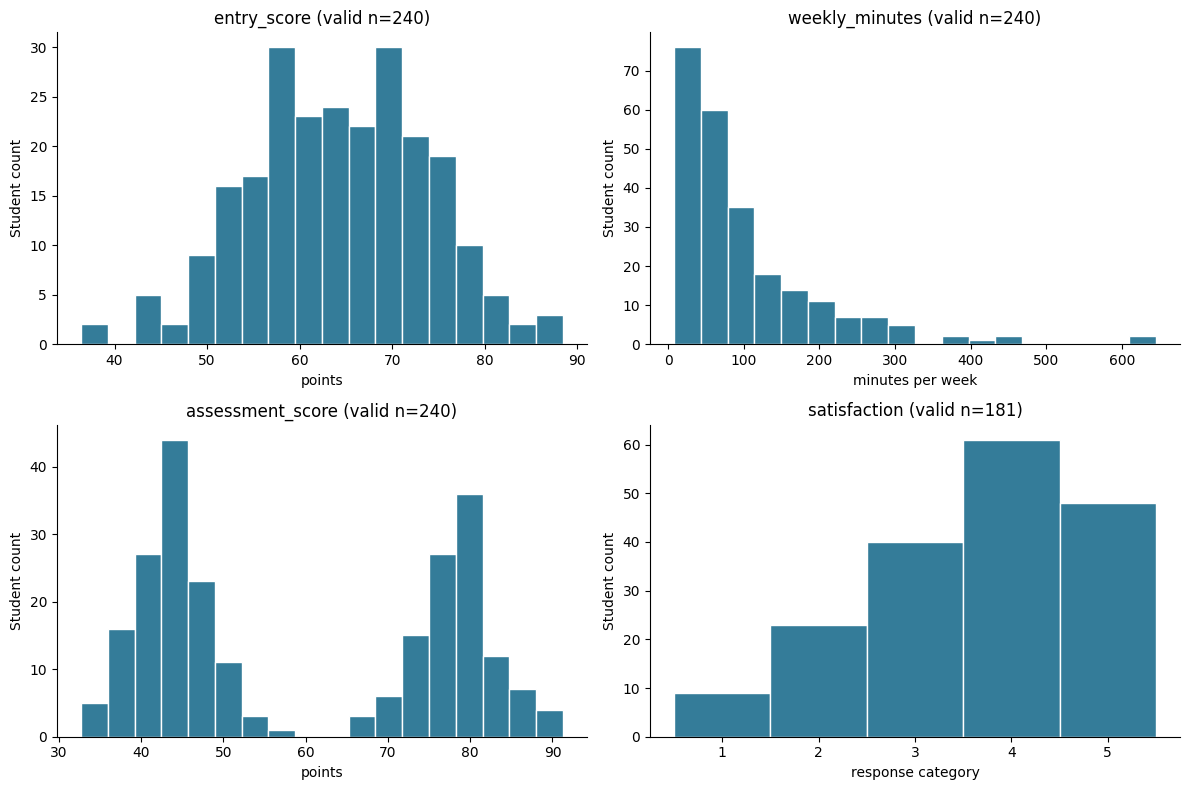

,count,mean,median,std,skew
entry_score,240.000,64.297,64.608,9.524,-0.080
weekly_minutes,240.000,101.688,67.387,99.615,2.346
assessment_score,240.000,59.387,50.070,18.003,0.168


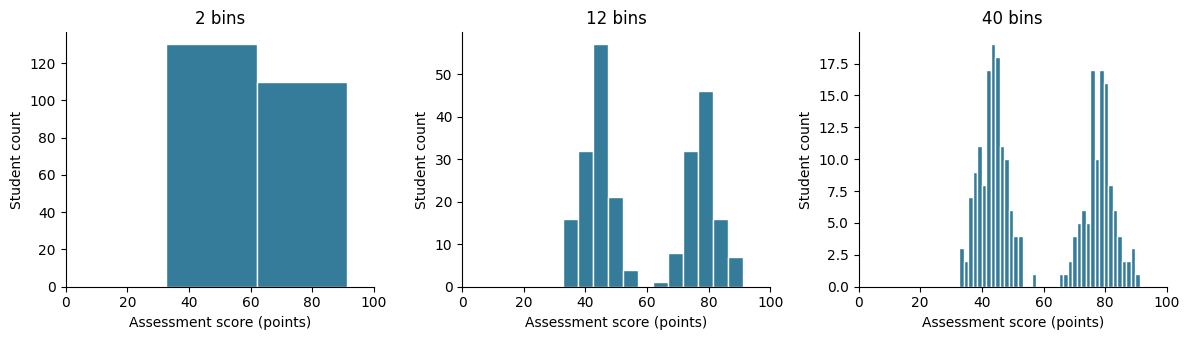

In [6]:
columns = ['entry_score','weekly_minutes','assessment_score','satisfaction']
units = ['points','minutes per week','points','response category']
fig, axes = plt.subplots(2,2,figsize=(12,8))
for ax,col,unit in zip(axes.flat,columns,units):
    x=students[col].dropna()
    ax.hist(x,bins=np.arange(.5,6,1) if col=='satisfaction' else 18,
            color='#347c99',edgecolor='white')
    ax.set(title=f'{col} (valid n={len(x)})',xlabel=unit,ylabel='Student count')
plt.tight_layout(); plt.show()
display(students[columns[:3]].agg(['count','mean','median','std','skew']).T)
fig, axes = plt.subplots(1,3,figsize=(12,3.5))
for ax,b in zip(axes,[coarse_bins,12,fine_bins]):
    ax.hist(students.assessment_score,bins=b,color='#347c99',edgecolor='white')
    ax.set(title=f'{b} bins',xlabel='Assessment score (points)',ylabel='Student count',xlim=(0,100))
plt.tight_layout(); plt.show()

### Your reasoning
**4A.** Write one shape sentence for **each of the four columns**. Include plot evidence; do not merely list a skewness number.

**4B.** Find a column where mean and median disagree. Give both values and explain the mechanism. Which centre and spread would you report for a typical observation?

**4C.** Compare the three histogram bin settings. What is concealed or exaggerated? Choose one and justify it. Does changing bins change the underlying mean?

**4D.** Does a nearly zero skewness or similar mean/median establish a normal distribution? Use the assessment-score plot to explain.

**Answer:**

**4A.**
- **Entry score:** roughly symmetric and mound-shaped, centred near 64 points, spreading from about 37 to 88, with no clear outliers (skew −0.08).
- **Weekly minutes:** strongly right-skewed. Most students are under 100 minutes, with a long tail out to about 640 and a few unusually high values (skew 2.35).
- **Assessment score:** bimodal, with two peaks near 44 and 79 points and a near-empty gap around 55-65. This is two groups, not one.
- **Satisfaction:** ordinal and left-skewed, rising from 1 to a peak at 4, with 5 slightly lower. Most responses are 4-5, with a tail of low ratings (n = 181).

**4B.** Weekly minutes: mean 101.7 vs median 67.4. The long right tail of large values pulls the mean up, while the median ignores how extreme they are. For a typical student, report the **median (67.4 minutes) with the IQR**, not the mean and SD.

**4C.**
- **2 bins:** hides the two peaks entirely and shows one block.
- **12 bins:** shows the two peaks and the gap clearly.
- **40 bins:** exaggerates noise with jagged, spiky bars, though the gap is still visible.

I'd choose **12 bins**, since it shows the structure without the noise. Changing bins changes only the picture, not the data, so the mean is unchanged.

**4D.** No. Assessment skew is 0.168 (near zero) and mean 59.4 is close to median 50.1, yet the plot is clearly bimodal with a gap, nothing like a normal bell. The two humps balance each other, so the summary numbers look benign. The mean (59.4) falls in the near-empty gap, where almost no students actually score, so it is not a typical value.

## 5 · Boxplots, flags, and hidden groups (15 min)
Box = Q1 to Q3; line = median. Fences = Q1 − 1.5×IQR and Q3 + 1.5×IQR. Whiskers end at the most extreme **observed** values inside the fences; they are not the fences themselves. Dots are candidates for investigation, not automatic deletion.

Here pandas and the plotting convention use linearly interpolated quartiles. Group summaries use sample SD (`ddof=1`).

,0
Q1,34.101
median,67.387
Q3,133.516
IQR,99.416
lower fence,-115.022
upper fence,282.640
lower whisker,7.580
upper whisker,275.868
flagged count,14.000


,record_id,weekly_minutes
8,9,388.970
22,23,307.110
24,25,289.120
39,40,321.756
63,64,379.816
93,94,314.691


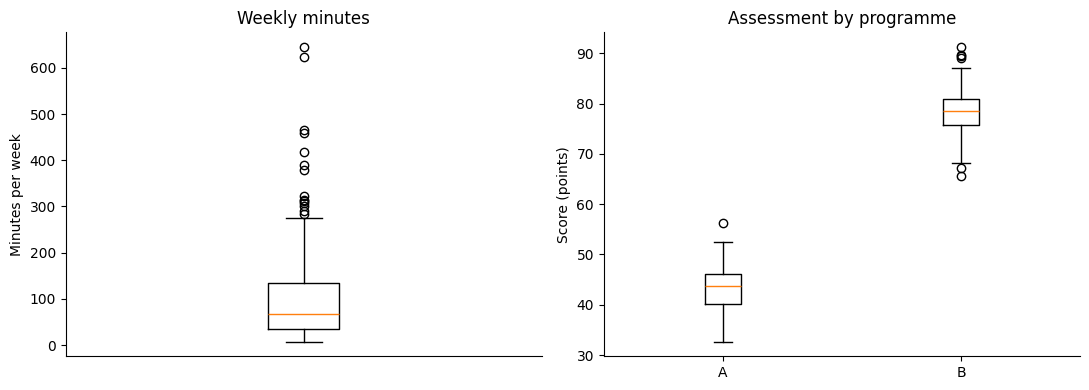

Overall assessment summary:


,assessment_score
count,240.000
mean,59.387
median,50.070
std,18.003


Programme summaries:


,count,mean,median,std
programme,,,,
A,130,43.435,43.649,4.541
B,110,78.238,78.481,4.913


In [7]:
x = students.weekly_minutes
q1,q3=x.quantile([.25,.75]); iqr=q3-q1
lower,upper=q1-1.5*iqr,q3+1.5*iqr
inside=x[(x>=lower)&(x<=upper)]
flagged=students[(x<lower)|(x>upper)]
display(pd.Series({'Q1':q1,'median':x.median(),'Q3':q3,'IQR':iqr,
    'lower fence':lower,'upper fence':upper,'lower whisker':inside.min(),
    'upper whisker':inside.max(),'flagged count':len(flagged)}))
display(flagged[['record_id','weekly_minutes']].head(6))
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].boxplot(x); axes[0].set(ylabel='Minutes per week',title='Weekly minutes',xticks=[])
axes[1].boxplot([students.loc[students.programme==g,'assessment_score'] for g in ['A','B']])
axes[1].set(xticks=[1,2],xticklabels=['A','B'],ylabel='Score (points)',title='Assessment by programme')
plt.tight_layout(); plt.show()
print('Overall assessment summary:')
display(students.assessment_score.agg(['count','mean','median','std']))
print('Programme summaries:')
display(students.groupby('programme').assessment_score.agg(['count','mean','median','std']))

### Your reasoning
**5A.** Using your Q1/Q3, show one fence calculation. State a whisker endpoint and explain why it differs from the corresponding fence. Describe a flagged record using its ID and minutes.

**5B.** Propose two checks before changing that record and one reason to retain it. What would you document if it were corrected? Do not delete it simply because it crosses a fence.

**5C.** Compare the overall assessment mean with both programme means and SDs. Would a single support session at the overall average meet both groups' needs? Give evidence and a better plan. Can these data prove that programme membership caused the difference?

**Answer:**

**5A.** Using Q1 = 34.101, Q3 = 133.516, IQR = 99.416:
- Upper fence = Q3 + 1.5 × IQR = 133.516 + 149.124 = **282.640 minutes**
- Lower fence = 34.101 − 149.124 = −115.022, so no low outliers are possible.

The upper whisker ends at **275.868**, the largest observation that is still within the fence. It sits below the fence because whiskers stop at real data points, not at the fence itself.

Flagged record example: record 9 logged **388.970 minutes** in the week, well above the 282.640 fence (14 records are flagged in total).

**5B.**
- **Check 1:** Verify the value at the source, such as the platform logs, for a recording or unit error.
- **Check 2:** Look at the student's other data and check whether the pattern is plausible (for example, whether they are consistently heavy users).
- **Reason to retain:** Minutes have no upper limit, so 389 minutes (about 6.5 hours) is plausible for a very engaged student. It is a genuine extreme, not an error.
- **If corrected, document:** the record ID, the original and corrected values, the reason, the evidence used, who changed it, and the date.

**5C.**
- **Overall:** mean 59.4, SD 18.0
- **A:** mean 43.4, SD 4.5 (n = 130)
- **B:** mean 78.2, SD 4.9 (n = 110)

The overall mean falls in the gap between the groups, and the overall SD is inflated by the group difference. Each group's SD is only about 4.5-4.9 points. A single session pitched at about 59 would fit almost nobody: it would be too advanced for A (about 16 points below it) and too basic for B (about 19 points above it).

**Better plan:** Run separate sessions, with extra support for Programme A and extension work for Programme B.

**Causation:** No. This is observational data. Programme A and B students may already differ (for example in entry score or study time), so the data can't prove programme membership caused the difference. That needs random assignment or controlling for confounders.

### Same mean and SD, different students
The next two small classes have the same mean and sample SD but different shapes. Values are shifted for your case. Inspect them before answering.

In [8]:
centre = int(round(small.mean()))
class_a = centre + np.array([-20,0,0,0,0,0,0,20])
class_b = centre + np.array([-10,-10,-10,-10,10,10,10,10])
for name,a in [('Class A',class_a),('Class B',class_b)]:
    print(name, a.tolist(), '| mean:',a.mean(),'| sample SD:',round(a.std(ddof=1),3))

Class A [37, 57, 57, 57, 57, 57, 57, 77] | mean: 57.0 | sample SD: 10.69
Class B [47, 47, 47, 47, 67, 67, 67, 67] | mean: 57.0 | sample SD: 10.69


### Your reasoning
**5D.** Sketch or describe each shape. Explain why the same mean and SD can lead to different tutoring plans. What information did the two statistics discard?

**Answer:**

**5D.**
**Shapes:**
- **Class A** [37, 57×6, 77]: a tall spike at 57 (6 of 8 students) with one student 20 points below and one 20 above. Most students are average, with two extremes.
- **Class B** [47×4, 67×4]: two equal clusters at 47 and 67 and nobody at 57. This is a split class with a gap in the middle.

**Different tutoring plans:**
- **Class A:** Teach to the middle, with a general session at about 57. Give one-to-one help to the student at 37 and an extension task to the student at 77.
- **Class B:** Run two groups, with catch-up support for the 47 group and enrichment for the 67 group. A single session pitched at 57 would suit no one, since no student actually scores 57.

**What the statistics discarded:** Mean 57 and SD 10.69 only say the centre and the typical distance from it. They hide the shape: where values cluster, whether there are gaps or two groups, and where individual extremes sit. That is why you plot the data first.

## 6 · When does 68–95–99.7 help? (10 min)
A normal model predicts approximately 68%, 95%, and 99.7% within 1, 2, and 3 SD of its mean. This is **not a guarantee for a finite dataset**, and symmetry alone is insufficient. We use sample mean/SD here to compare observed proportions with the model.

In [9]:
rows=[]
for col in ['entry_score','weekly_minutes','assessment_score']:
    x=students[col]; m=x.mean(); sd=x.std(ddof=1)
    for k in [1,2,3]:
        rows.append({'column':col,'SD distance':k,'lower':m-k*sd,'upper':m+k*sd,
                     'observed %':100*x.between(m-k*sd,m+k*sd).mean(),
                     'normal model %':{1:68,2:95,3:99.7}[k]})
display(pd.DataFrame(rows))

,column,SD distance,lower,upper,observed %,normal model %
0,entry_score,1,54.773,73.822,65.833,68.000
1,entry_score,2,45.249,83.346,95.000,95.000
2,entry_score,3,35.725,92.870,100.000,99.700
3,weekly_minutes,1,2.073,201.303,87.083,68.000
4,weekly_minutes,2,-97.542,300.918,95.417,95.000
5,weekly_minutes,3,-197.157,400.533,97.917,99.700
6,assessment_score,1,41.384,77.389,57.083,68.000
7,assessment_score,2,23.381,95.392,100.000,95.000
8,assessment_score,3,5.378,113.395,100.000,99.700


### Your reasoning
**6A.** Give your entry-score interval within 1 SD and observed percentage. Explain why it need not be exactly 68%.

**6B.** Which column is the most plausible candidate for a normal approximation? Use both shape and proportions. Explain why applying the rule to either of the other columns could mislead.

**6C.** If an observed proportion happens to be near 95%, has normality been proven? Why not?

**Answer:**

**6A.** Entry score within 1 SD: **54.773 to 73.822 points**, containing **65.833%** of students (vs 68% in the model). It needn't be exactly 68% because the rule is a theoretical prediction for a perfectly normal distribution. A real, finite sample has random variation, and its shape is never exactly normal.

**6B.** **Entry score** is the most plausible candidate.
- **Shape:** roughly symmetric and mound-shaped, with skew −0.08.
- **Proportions:** 65.8%, 95.0%, 100% vs 68%, 95%, 99.7%, all close.

The other columns could mislead:
- **Weekly minutes:** the right skew gives 87.1% within 1 SD (vs 68%). Its 2 SD interval runs down to −97.5 minutes, which is impossible.
- **Assessment score:** bimodal, with 57.1% within 1 SD and 100% within 2 SD. The mean sits in the gap, so the rule describes no real group.

**6C.** No. One proportion near 95% is only one piece of evidence. Different shapes can share the same proportion at one cut-off. For example, assessment score hits 100% at 2 SD, yet is clearly bimodal. Normality needs the whole shape (a histogram, symmetry, tails) and all the proportions to line up, and even then it's only an approximation, not proof.

## 7 · Relative to whom? (15 min)
A z-score is `(value − reference mean) / reference SD`. It is unitless; the reference SD must be positive. Positive means above the mean, not automatically good. Computing z does not require normality; converting it into a normal-model rarity does.

**Prediction:** the selected student's raw score will stay fixed while the reference group changes. Must their z-score remain fixed? Explain before running.

### Your reasoning
**7A. Prediction:** explain which ingredients can change and why.

**Answer:**

7A. No, the z-score need not stay fixed.

The raw value stays the same, but the reference mean and reference SD change when the reference group changes. Since z = (value − reference mean) / reference SD, a different mean or SD gives a different z.

In [10]:
focus=students.iloc[focus_index]
print('Selected record:',int(focus.record_id),'| programme:',focus.programme,'| entry score:',focus.entry_score)
rows=[]
for label,ref in [('Whole cohort',students.entry_score),
                  ('Programme A',students.loc[students.programme=='A','entry_score']),
                  ('Programme B',students.loc[students.programme=='B','entry_score'])]:
    sd=ref.std(ddof=1)
    rows.append({'reference':label,'n':len(ref),'mean':ref.mean(),'sample SD':sd,
                 'z':(focus.entry_score-ref.mean())/sd if sd>0 else np.nan})
display(pd.DataFrame(rows))
students['entry_z_cohort']=(students.entry_score-students.entry_score.mean())/students.entry_score.std(ddof=1)
print('Standardised column mean / sample SD:',students.entry_z_cohort.mean(),students.entry_z_cohort.std(ddof=1))
# A separate personalised example separates distance from rank.
rank_times = np.r_[np.arange(1,10),int(46 + seed % 21)].astype(float)
target=9.
print('Practice minutes:',rank_times.tolist())
print('Target:',target,'| z:',(target-rank_times.mean())/rank_times.std(ddof=1),
      '| percentile rank (at or below):',100*np.mean(rank_times<=target))

Selected record: 225 | programme: A | entry score: 88.45051853350766


,reference,n,mean,sample SD,z
0,Whole cohort,240,64.297,9.524,2.536
1,Programme A,130,65.407,9.980,2.309
2,Programme B,110,62.985,8.822,2.887


Standardised column mean / sample SD: 8.659739592076221e-16 1.0000000000000002
Practice minutes: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 57.0]
Target: 9.0 | z: -0.07209233732553486 | percentile rank (at or below): 90.0


### Your reasoning
**7B.** Show one z-score calculation from the table. Write its interpretation with the reference group and direction. Which reference answers “unusual within this student's own programme”?

**7C.** Explain the mean and SD of the standardised column. Would standardising programme codes be meaningful? What if all values in a reference group were identical?

**7D.** In the practice-time example, how can 9 minutes be below the mean yet at the 90th percentile? Use the extreme observation in your explanation. Why should you not automatically interpret z=2 as a particular percentile?

**7E.** A bottle process has reference mean 100 mL and SD 2 mL. Its explicitly agreed specification is 94–106 mL inclusive. For bottles of 104 and 108 mL, calculate z and decide acceptance. Explain why rejecting a bottle does not mean deleting its measurement, and why z alone does not set the acceptance rule.

**Answer:**

**7B.** Record 225, whole cohort: z = (88.45 − 64.297) / 9.524 = **+2.54**. This student's entry score is about 2.5 SDs **above** the whole-cohort mean. Within Programme A, z = (88.45 − 65.407) / 9.980 = **+2.31**. The **Programme A** reference answers "unusual within this student's own programme.

**7C.**
- **Mean ≈ 0, SD = 1:** Standardising subtracts the mean (centring it at 0) and divides by the SD (scaling it to 1). The 8.66e-16 is just floating-point rounding, so it is effectively 0.
- **Programme codes:** Not meaningful. They are nominal labels, so a mean and SD of them have no interpretation.
- **Identical values:** The SD is 0, so z would divide by zero and is undefined.

**7D.** The mean is (1+…+9+57)/10 = 10.2 minutes. The extreme value 57 pulls the mean up, so 9 is below it (z ≈ −0.07). But 9 is still higher than or equal to 9 of the 10 values, so it sits at the 90th percentile. Don't read z = 2 as a fixed percentile, because that only holds if the data are approximately normal (about the 97.7th percentile). In skewed data, the same z can sit at a very different percentile.

**7E.**
- **104 mL:** z = (104 − 100)/2 = **+2** → inside 94-106 → **accept**.
- **108 mL:** z = (108 − 100)/2 = **+4** → outside → **reject**.

Rejecting a bottle doesn't mean deleting its measurement. It is a real observation, and it must stay in the record for process monitoring, audits, and tracing the cause. And z alone doesn't set the rule: z only describes distance from the process mean, while the acceptance rule comes from the agreed specification. For example, 94 mL has z = −3 yet is accepted, because it is inside the spec.

## 8 · Your recommendation (15 min)
The final case uses the same weekly-minute data. Your assigned request appears below. Choose your primary summary for **that decision**, then explain what you would report for the other decision.

- **Typical use:** describe the experience of a typical student.
- **Total workload:** estimate the recorded cohort's total platform workload for the week; distinguish an observed total from a forecast of a future week.

This is a decision exercise. There is no universally best average.

In [11]:
print('YOUR REQUEST:',scenario)
x=students.weekly_minutes
print('Case:',case_code)
display(pd.Series({'valid n':x.count(),'mean':x.mean(),'median':x.median(),
    'sample SD':x.std(ddof=1),'Q1':x.quantile(.25),'Q3':x.quantile(.75),
    'IQR':x.quantile(.75)-x.quantile(.25),'total minutes':x.sum()}))

YOUR REQUEST: total workload
Case: b99e1e9b7f


,0
valid n,240.000
mean,101.688
median,67.387
sample SD,99.615
Q1,34.101
Q3,133.516
IQR,99.416
total minutes,24405.083


### Your reasoning
**8A. Final note — approximately 150 words:** explain why you would not report the weekly-minute mean alone. Address your assigned request and include: case code; population and valid n; units; chosen centre and spread; two numerical pieces of evidence; shape; what your summary hides; what you would report for the other request; and one limitation. Do not claim a cause or treat this synthetic cohort as real university evidence.

**8B. Transfer check:** suppose the highest-use student's minutes doubled. Without rerunning, predict the direction of change in the mean and total, and whether the median would change. Explain which recommendation would be more affected.

**Answer:**

**8A. Final note**

**Case b99e1e9b7f, total workload.** Population: 240 synthetic students, all with valid weekly minutes, in one week. For total workload, the mean links directly to the total: 101.688 minutes × 240 = **24,405 minutes** (about 407 hours), which is an observed total, not a forecast for a future week. The mean alone isn't enough, though. It is pulled up by a long right tail: the median is 67.4 minutes, the SD is 99.6 (roughly the mean), the skew is 2.35, and 14 records are flagged above the 282.6 fence. The histogram is strongly right-skewed. The mean hides that most students use far less than 101.7 minutes. For typical use, I would report the **median (67.4) with the IQR (34.1-133.5)**. One limitation: this is a synthetic, single-week, observational dataset, so it supports no causal claim or real-university conclusion.

**8B. Transfer check:** If the highest user's minutes doubled:
- **Mean and total:** both would **increase**. The total rises by that student's original minutes (about 645), and the mean by roughly 645/240 ≈ 2.7 minutes.
- **Median:** **unchanged**. The student is already the highest-ranked value, so the middle values don't move.

The **total workload recommendation** would be more affected, since totals and means use every value, while the typical-use median is resistant to this change.

## Submission checklist
- [ ] My name, student ID, and case code are present and consistent.
- [ ] I kept predictions and explained any revisions.
- [ ] I answered 1A–8B, including the hand calculations and approximately 150-word note.
- [ ] Four column plots and all other supplied results are visible.
- [ ] My answers cite my own numbers, units, group definitions, and plot evidence.
- [ ] I stated the quartile convention and sample/population SD choice where relevant.
- [ ] I did not automatically remove outlier candidates or make unsupported causal claims.
- [ ] I restarted and ran all cells using my own ID, then saved with outputs.

Save as **`STUDENTID_Lab2_FDS.ipynb`**, replacing STUDENTID with your ID. Submit through the course's announced channel and follow its current email-subject rule. The reflection belongs inside this notebook; no separate report is needed.

### What a strong submission demonstrates
Correct calculations are the starting point. Strong work explains **why** a summary fits the question, distinguishes observations from assumptions, recognises what averages conceal, and supports a decision with personalised evidence.

*Aligned with Week 2: Describing Data, slides 2–65. This lab focuses on describing and interpreting data; full data-cleaning procedures follow in Week 3.*